<a href="https://colab.research.google.com/github/sivasooryagiri/Learn-PyTorch-for-deep-learning-in-a-day--Notes/blob/main/PyTorch_ViT_paper_replicating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Getting setup

In [1]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.9.0+cu126
0.24.0+cu126


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms

# Try to get torchinfo, instll it if it does not exist
try:
  from torchinfo import summart
except:
  print("[INFO] couldn't find torchinfo... installing it.")
  !pip install -q torchinfo
  from torchinfo import summary

# Try to import the going_modular directory, download it from Github if doesn't exist
try:
  from going_modular.going_modular import data_setup, enginge
  from helper_functions import download_data, set_seeds, plot_loss_curves
except:
  print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub")
  !git clone https://github.com/mrdbourke/pytorch-deep-learning
  !mv pytorch-deep-learning/going_modular .
  !mv pytorch-deep-learning/helper_functions.py .
  !rm -rf pytorch-deep-learning
  from going_modular.going_modular import data_setup, engine
  from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 24.75 MiB/s, done.
Resolving deltas: 100% (2656/2656), done.
Updating files: 100% (248/248), done.


In [3]:
# Setting device type
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. Get Data

In [4]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination ="pizza_steak_sushi")

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


In [5]:
# Setup directory paths to train and test images
train_dir = image_path/"train"
test_dir = image_path/"test"

# 2. Create Dataset and Dataloaders

In [6]:
#2.1
# Create image size (form table 3 in the vit paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])
print(f"Manually crated transforms: {manual_transforms}")

Manually crated transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
#2.2
# set the batch size
BATCH_SIZE = 32
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size = BATCH_SIZE
)

In [8]:
#2.3
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))
image, label = image_batch[0], label_batch[0]
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

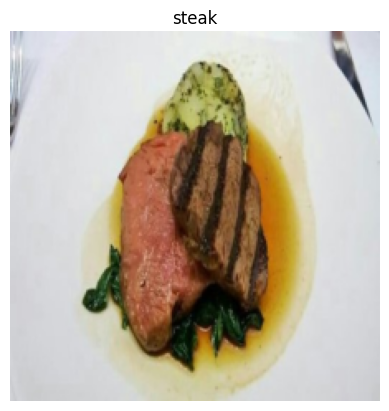

In [9]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

### Skiping 3. as its theory


# 4. Equation 1: Split data into patches and creating the class, position and patch embeding

$$
\mathbf{z}_0 =
\left[
\mathbf{x}_{\text{class}};
\mathbf{x}_p^{1} \mathbf{E};
\mathbf{x}_p^{2} \mathbf{E};
\cdots;
\mathbf{x}_p^{N} \mathbf{E}
\right]
+ \mathbf{E}_{\text{pos}},
\quad
\mathbf{E} \in \mathbb{R}^{(P^2 \cdot C)\times D},
\quad
\mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1)\times D}
$$


### 4.1 Calculating patch embeding input and output shapes by hand

In [10]:
height = 224
width = 224
color_channels = 3
patch_size = 16

# Calculate N (number of patches)
number_of_patches = int((height*width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}, width (W={width}) and patch size (P={patch_size}): {number_of_patches}))")

Number of patches (N) with image height (H=224, width (W=224) and patch size (P=16): 196))


In [11]:
# Input shape (this is the size of a single Image)
embedding_layer_input_shape = (height, width, color_channels)
# Output shapebeding input and
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2d image): {embedding_layer_input_shape}")
print(f"Output shape (single 2d image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2d image): (224, 224, 3)
Output shape (single 2d image flattened into patches): (196, 768)


### 4.2 Tuning a simple image into patches

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

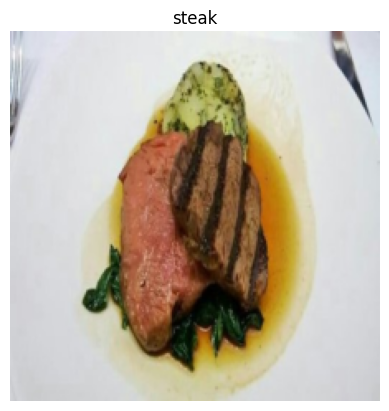

In [12]:
# A sample image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

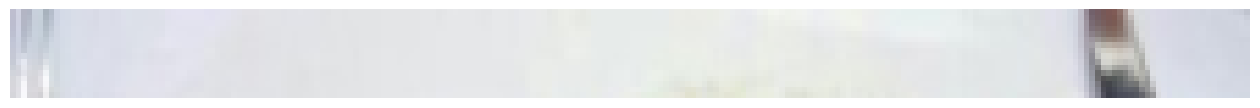

In [13]:
# Ploting a patch of the image above
image_permuted = image.permute(1,2,0)
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
plt.axis(False)

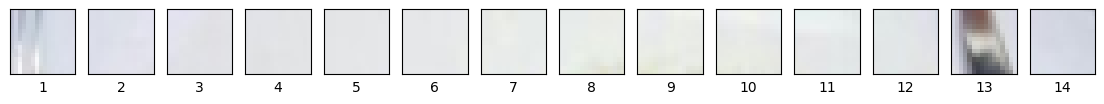

In [14]:
# Setup hyperparameters and make sure img_size and patch_size are  compatible
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0, "Image size must be divisible"

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                       ncols=img_size // patch_size,
                       figsize=(num_patches, num_patches),
                       sharex=True,
                       sharey=True)
for i, patch in enumerate(range(0, img_size, patch_size)):
  axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :])
  axs[i].set_xlabel(i+1) # set the label
  axs[i].set_xticks([])
  axs[i].set_yticks([])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


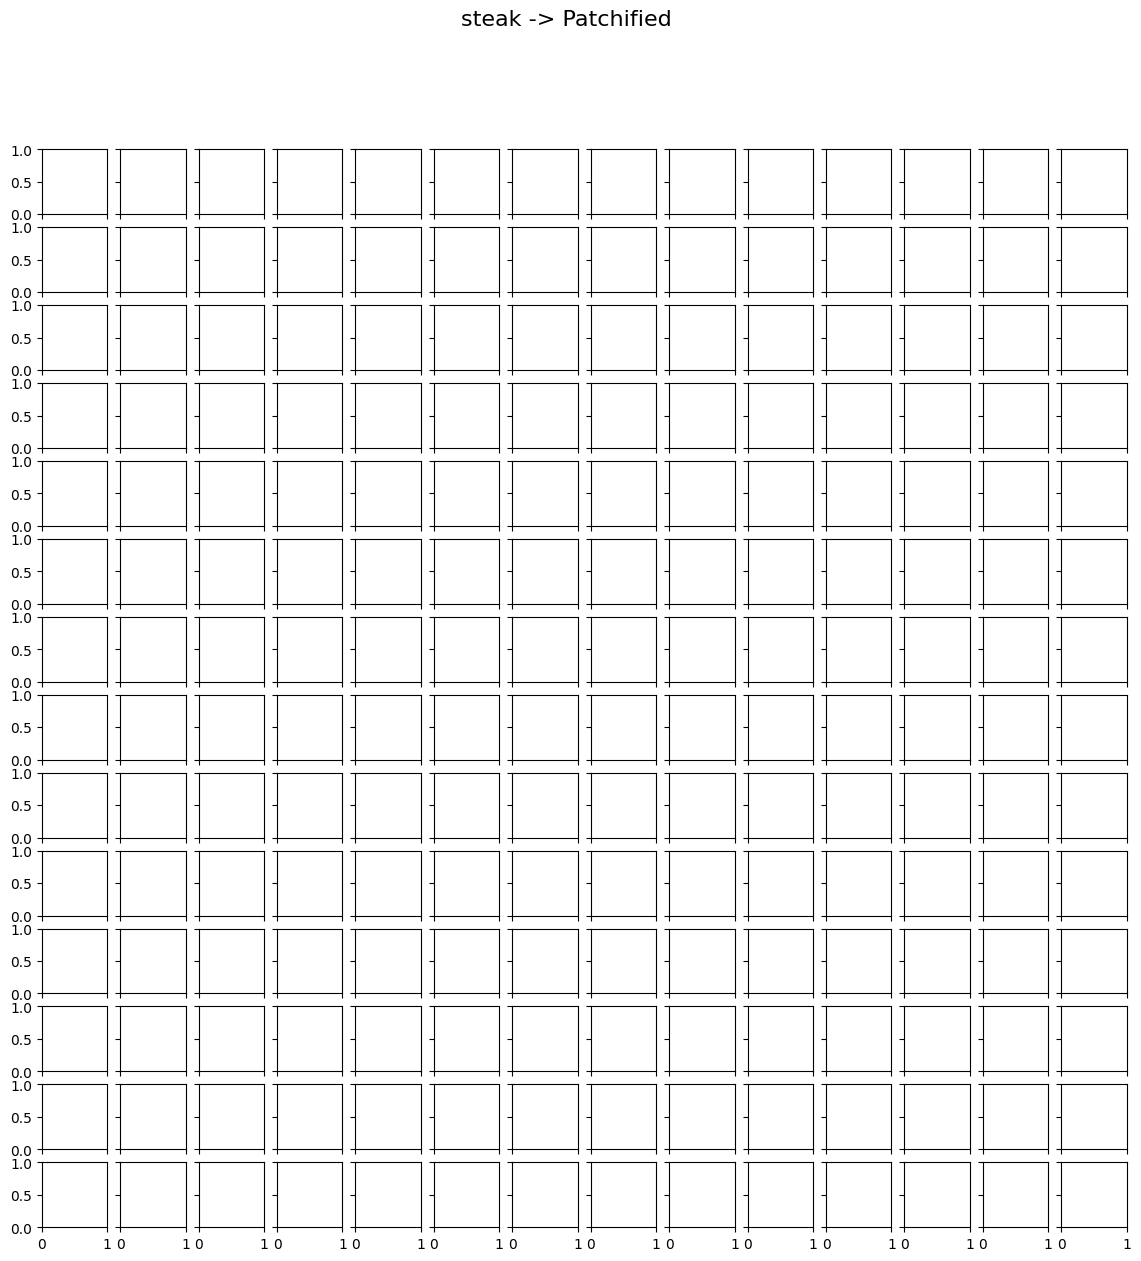

In [15]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
# for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
#     for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

#         # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
#         axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
#                                         patch_width:patch_width+patch_size, # iterate through width
#                                         :]) # get all color channels

#         # Set up label information, remove the ticks for clarity and set labels to outside
#         axs[i, j].set_ylabel(i+1,
#                              rotation="horizontal",
#                              horizontalalignment="right",
#                              verticalalignment="center")
#         axs[i, j].set_xlabel(j+1)
#         axs[i, j].set_xticks([])
#         axs[i, j].set_yticks([])
#         axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

### 4.3 Creating image patches with torch.nn.Conv2d()

In [16]:
# Set the patch size
patch_size=16

# Create the Conv2d layer with hyperparameters form the VIT paper.
conv2d = nn.Conv2d(in_channels=3,
                   out_channels=786,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)


In [17]:
image_out_of_conv = conv2d(image.unsqueeze(0))
print(image_out_of_conv.shape)


torch.Size([1, 786, 14, 14])


so even though the shape is in the form [1,786,14,14] it doesn't matter. The 16 is inside 786 it actualy "16* 16*3".
In simple think like [1,14,14,786] This will solve your confusion

Showing random convolutional feature maps from indexes: [118, 754, 382, 112, 664]


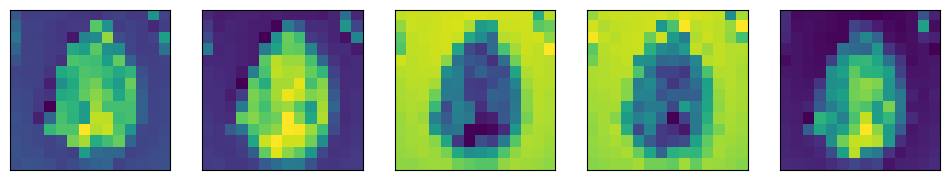

In [18]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [19]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
# single_feature_map, single_feature_map.requires_grad

### 4.4 Flatterning the patch embedings with torch.nn.Flatten()

In [20]:
# Create a flatten layer
flatten = nn.Flatten(start_dim=2,
                     end_dim=3)

In [21]:
# Lets see the working
print(f"Image shape: {image.shape}")
image_out_of_conv = conv2d(image.unsqueeze(0))
print(f"Output from conv shape = {image_out_of_conv.shape}")
# Now lets flattern and see the out
image_out_of_conv_flattend = flatten(image_out_of_conv)
print(f"Flattend output shape = {image_out_of_conv_flattend.shape}")

Image shape: torch.Size([3, 224, 224])
Output from conv shape = torch.Size([1, 786, 14, 14])
Flattend output shape = torch.Size([1, 786, 196])


doing a reshape as total patch should come at 1 st pos not at 2nd *pos*

In [22]:
image_out_of_conv_flattend_reshaped = image_out_of_conv_flattend.permute(0,2,1)
print(f"shape of output reshaped: {image_out_of_conv_flattend_reshaped.shape}")

shape of output reshaped: torch.Size([1, 196, 786])


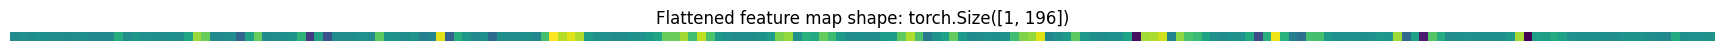

In [23]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattend_reshaped[:, :, 0] # index: (batch_size, number_of_patches, embedding_dimension)

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

### 4.5 Turning the ViT patch embedding layer into PyTorch module

In [24]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
  """Turns a 2D input image into a 1D sequence learnable embedding vector.
  """
  def __init__(self,
               in_channels:int=3,
               patch_size:int=16,
               embedding_dim:int=768):
    super().__init__()
    # 3. Create a layer to turn an image into patches
    self.patcher =nn.Conv2d(in_channels=in_channels,
                            out_channels=embedding_dim,
                            kernel_size=patch_size,
                            stride=patch_size,
                            padding=0)
    # 4. Create a layer of flatten
    self.flatten = nn.Flatten(start_dim=2,
                              end_dim=3)
  def forward(self, x):
    # Create assertion to check that inputs are the correct shape
    image_resolution = x.shape[-1]
    assert image_resolution % patch_size ==0, f"Input image size must be divisible by patch and image size: {image_resolution}, patch size: {patch_size}"

    # Perform the forward pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)

    return x_flattened.permute(0, 2, 1)



In [25]:
# Let's test it now
set_seeds()

patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Output patch embeding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embeding shape: torch.Size([1, 196, 768])


In [26]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
# random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# # Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
# summary(PatchEmbedding(),
#         input_size=random_input_image, # try swapping this for "random_input_image_error"
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])

### 4.6 Creating the class token embedding


In [27]:
# View the patch embedding and patch embedding shape
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embeding_dimention]")

tensor([[[-0.9115,  0.2843, -0.2503,  ...,  0.7165, -0.3478,  0.2789],
         [-0.9275,  0.2585, -0.2593,  ...,  0.7081, -0.4188,  0.3143],
         [-0.9172,  0.2486, -0.2526,  ...,  0.7081, -0.4283,  0.3325],
         ...,
         [-0.8673,  0.2385, -0.2450,  ...,  0.6627, -0.3954,  0.3070],
         [-0.8566,  0.2273, -0.2378,  ...,  0.6481, -0.3866,  0.3049],
         [-0.8253,  0.2209, -0.2366,  ...,  0.6363, -0.3803,  0.2980]]],
       grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embeding_dimention]


In [28]:
# Get the batch size and embedding dims
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class tocken embedding as a learnable parameter that shares as the embedding dim(D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad= True)
# Show the first 10 examples of the class_token
print(class_token[:,:, :10])
print(f"Class token shape: {class_token.shape} -> [batch_size, no_of_tokens, embedding_dim]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, no_of_tokens, embedding_dim]


In [29]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1)
print(patch_embedded_image_with_class_embedding.shape[2])

768


### 4.7 Creating the position embedding

In [30]:
# Calaculate N (number of patches)
number_of_patches = int((height * width)/ patch_size**2)

# Get embedding dim
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embeding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension,
                                             requires_grad=True))
# Show the first 10 embeding values
print(position_embedding[:,:10,:10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [31]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positonal embeddings added shape: {patch_and_position_embedding.shape}-> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.0885, 1.2843, 0.7497,  ..., 1.7165, 0.6522, 1.2789],
         [0.0725, 1.2585, 0.7407,  ..., 1.7081, 0.5812, 1.3143],
         ...,
         [0.1327, 1.2385, 0.7550,  ..., 1.6627, 0.6046, 1.3070],
         [0.1434, 1.2273, 0.7622,  ..., 1.6481, 0.6134, 1.3049],
         [0.1747, 1.2209, 0.7634,  ..., 1.6363, 0.6197, 1.2980]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positonal embeddings added shape: torch.Size([1, 197, 768])-> [batch_size, number_of_patches, embedding_dimension]


### 4.8 putting it all together: from image to embedding

In [32]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of orginal image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dim
x = image.unsqueeze(0)

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)
# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1 , embedding_dimension),
                           requires_grad=True)
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding ot patch embedding
patch_embedding_class_token = torch.cat((class_token,patch_embedding), dim=1)

# 8. Create position embeddng
number_of_patches = int((height*width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True)

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape:{patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch and position embedding shape:torch.Size([1, 197, 768])


# 5. Equation 2: Multi-Head Attention (MSA)

### 5.1 LayerNorm (LN) layer

In [33]:
class MultiheadsSelfAttentionBlock(nn.Module):
  """Creates a multi-head self-Attention block ("MSA block" for short.)
  """
  def __init__(self,
              embedding_dim:int=768,
              num_heads:int=12,
              attn_dropout:float=0):
    super().__init__()

    # Create a Norm layer
    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

    # Create the Multi-Head Attention (MSA) layer
    self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                num_heads=num_heads,
                                                dropout=attn_dropout,
                                                batch_first=True)

  def forward(self, x):
    x = self.layer_norm(x)
    attn_output, _ = self.multihead_attn(query=x,
                                         key=x,
                                         value=x,
                                         need_weights=False)
    return attn_output

In [34]:
# Create an instance of MSABlock
multihead_self_attention_block = MultiheadsSelfAttentionBlock(embedding_dim=768,
                                                              num_heads=12)
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)

print(f"Input shape of MSA block:{patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block:torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


# 6. Equation 3: Multilayer Perceptron (MLP)

In [35]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim:int=768,
               mlp_size:int=3072,
               dropout:float=0.1):
    super().__init__()

    # Create the norm_layer
    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

    # Create the multilayer perceptron(MLP) layer(s)
    self.mlp = nn.Sequential(
        nn.Linear(in_features=embedding_dimension,
                  out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(p=dropout)
    )
  def forward(self, x):
    x = self.layer_norm(x)
    x = self.mlp(x)
    return x

In [36]:
# lets create a instance of MLP block
mlp_block = MLPBlock(embedding_dim=768,
                     mlp_size=3972,
                     dropout=0.1)
# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


# 7. Create the Transformer Encoder

In [37]:
class TransformerEncoderBlock(nn.Module):
  """Create a Trasformer Encoder block."""
  def __init__(self,
               embedding_dim:int=768,
               num_heads:int=12,
               mlp_size:int=3072,
               mlp_dropout:float=0.1,
               attn_dropout:float=0):
    super().__init__()
    # Create MSA block (eq2)
    self.msa_block = MultiheadsSelfAttentionBlock(embedding_dim=embedding_dim,
                                                  num_heads=num_heads,
                                                  attn_dropout=attn_dropout)
    self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                              mlp_size=mlp_size,
                              dropout=mlp_dropout)

  # Create forward method / also adding residual connection
  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x
    return x

In [38]:
# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoderBlock()

# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
# summary(model=transformer_encoder_block,
#         input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])

In [39]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

# 8. Putting it all together

In [40]:
class ViT(nn.Module):
  """ Creates a vision Trasformer architecture with ViT-Base hyperparameters by default."""
  def __init__(self,
               img_size:int=224,
               in_channels:int=3,
               patch_size:int=16,
               num_trasformer_layers:int=12,
               embedding_dim:int=768,
               mlp_size:int=3072,
               num_heads:int=12,
               attn_dropout:float=0,
               mlp_dropout:float=0.1,
               embedding_dropout:float=0.1,
               num_classes:int=1000):
    super().__init__()

    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image_size: {img_size}, patch_size: {patch_size}"
    self.num_patches = (img_size * img_size) // patch_size**2
    self.class_embedding = nn.Parameter(data=torch.rand(1,1,embedding_dim),
                                        requires_grad=True)
    self.position_embedding = nn.Parameter(data=torch.rand(1, self.num_patches+1, embedding_dim))
    self.embedding_dropout = nn.Dropout(p=embedding_dropout)
    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)
    self.trasformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                      num_heads=num_heads,
                                                                      mlp_size=mlp_size,
                                                                      mlp_dropout=mlp_dropout) for _ in range(num_trasformer_layers)])
    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features=num_classes))
  def forward(self, x):
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size, -1, -1)
    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = self.position_embedding + x
    x = self.embedding_dropout(x)
    x = self.trasformer_encoder(x)
    x = self.classifier(x[:,0])
    return x

In [41]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[-0.3246, -0.4174, -0.0490]], grad_fn=<AddmmBackward0>)

In [42]:
from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)                           [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                      [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                     [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (trasformer_encoder)                            [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           [32, 197, 768]       [32, 197, 768]

# 9. Setting up training code for our ViT model

In [44]:
from going_modular.going_modular import engine
# Setup the optimizer to optimize our ViT model parameters from the ViT paper
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             betas=(0.9,0.999),
                             weight_decay=0.3)
loss_fn = torch.nn.CrossEntropyLoss()
set_seeds()
results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 4.1234 | train_acc: 0.2695 | test_loss: 1.4354 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.6173 | train_acc: 0.3945 | test_loss: 3.5057 | test_acc: 0.2604
Epoch: 3 | train_loss: 1.5670 | train_acc: 0.4570 | test_loss: 2.2242 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.7728 | train_acc: 0.2656 | test_loss: 1.9355 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.2585 | train_acc: 0.2812 | test_loss: 1.3640 | test_acc: 0.2604
Epoch: 6 | train_loss: 1.2330 | train_acc: 0.2812 | test_loss: 1.6605 | test_acc: 0.1979
Epoch: 7 | train_loss: 1.1253 | train_acc: 0.4570 | test_loss: 1.5143 | test_acc: 0.1979
Epoch: 8 | train_loss: 1.1157 | train_acc: 0.4297 | test_loss: 1.4418 | test_acc: 0.2604
Epoch: 9 | train_loss: 1.1908 | train_acc: 0.2891 | test_loss: 1.1916 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.2733 | train_acc: 0.2344 | test_loss: 1.9523 | test_acc: 0.2604


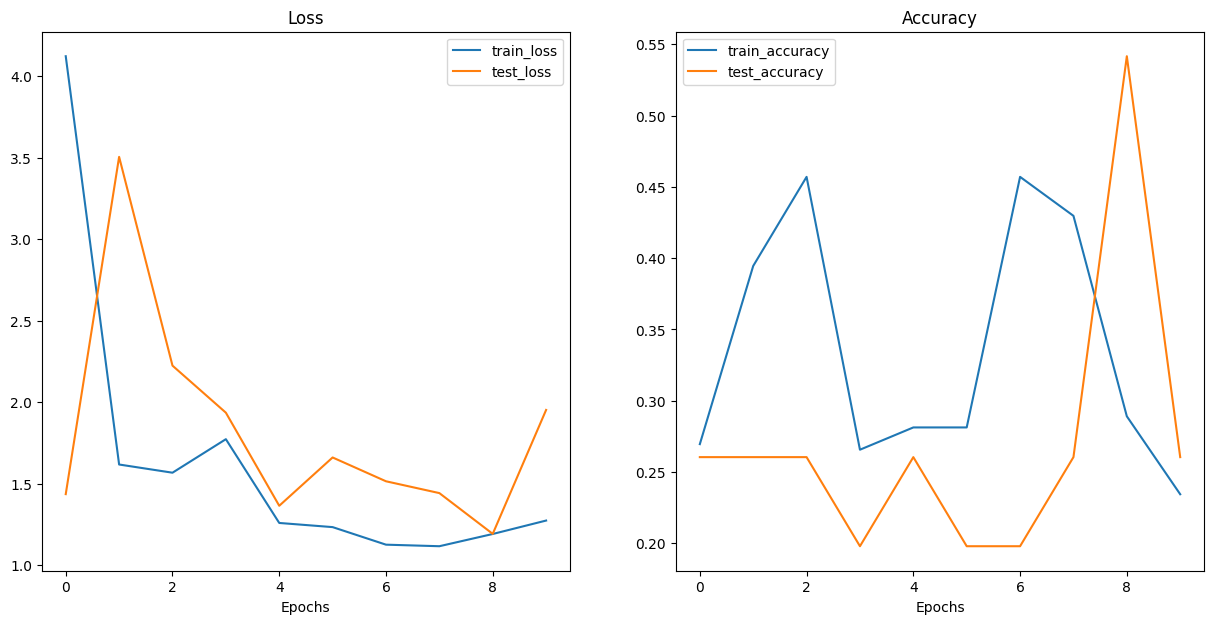

In [45]:
# lets plot some curves
from helper_functions import plot_loss_curves
plot_loss_curves(results)

In [47]:
from going_modular.going_modular import utils

utils.save_model(model=vit,
                 target_dir="models",
                 model_name="08_vit_feature_extractor.pth")

[INFO] Saving model to: models/08_vit_feature_extractor.pth
